# MESSAGEix vs GCAM — Current Measures Comparison

Compares two models: **MSG** (MESSAGEix-Pakistan) and **GCAM** (GCAM-Pakistan) under the Current Measures scenario.

In [63]:
import pandas as pd
import pyam
import matplotlib.pyplot as plt
import numpy as np

# Load MSG
_msg_raw = pd.read_excel('data/MESSAGEix-Pakistan_CM.xlsx')
_msg_raw.columns = _msg_raw.columns.astype(str)
_msg_raw = _msg_raw.loc[:, ~_msg_raw.columns.str.lower().str.startswith("unnamed:")]

# Load GCAM file once, convert EJ/yr -> PJ/yr to match MSG units
_gcam_all = pd.read_excel('data/GCAM-Pakistan_CM.xlsx')
_gcam_all.columns = _gcam_all.columns.astype(str)
_gcam_all = _gcam_all.loc[:, ~_gcam_all.columns.str.lower().str.startswith("unnamed:")]
_year_cols = [c for c in _gcam_all.columns if c.isdigit()]
_ej_mask = _gcam_all['Unit'] == 'EJ/yr'
_gcam_all.loc[_ej_mask, _year_cols] = _gcam_all.loc[_ej_mask, _year_cols] * 1000
_gcam_all.loc[_ej_mask, 'Unit'] = 'PJ/yr'

_gcam_cm  = _gcam_all[_gcam_all['Scenario'] == 'CurrentMeasures'].reset_index(drop=True)
_gcam_ref = _gcam_all[_gcam_all['Scenario'] == 'Reference'].reset_index(drop=True)

SCENARIOS = [
    ('MSG',      pyam.IamDataFrame(_msg_raw)),
    ('GCAM-CM',  pyam.IamDataFrame(_gcam_cm)),
    ('GCAM-Ref', pyam.IamDataFrame(_gcam_ref)),
]

YEARS     = [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2070]
KEY_YEARS = [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2070]

SCENARIO_COLORS  = {'MSG': "#000000", 'GCAM-CM': "#1519db", 'GCAM-Ref': "#cf0404"}
SCENARIO_MARKERS = {'MSG': 'o',       'GCAM-CM': 'o',       'GCAM-Ref': 'o'}


In [64]:
def stacked_bar_comparison(variables, colors, labels, title, ylabel='Energy (PJ)', scale=1, years=KEY_YEARS):
    fig, ax = plt.subplots(figsize=(16, 7))
    w, gap_year, gap_scen = 0.8, 1.8, 0.05
    added, x = set(), 0
    year_centers, bar_positions, bar_labels = [], [], []

    for yi, year in enumerate(years):
        if yi > 0:
            x += gap_year
        group_start = x
        for sname, sdf in SCENARIOS:
            bottom = 0
            for var in variables:
                filt = sdf.filter(variable=var, year=year)
                val = filt.timeseries().values[0][0] * scale if not filt.empty else 0
                if val <= 0:
                    continue
                lbl = labels[var] if labels[var] not in added else ''
                if lbl:
                    added.add(labels[var])
                ax.bar(x, val, w, bottom=bottom, color=colors[var], label=lbl)
                bottom += val
            bar_positions.append(x)
            bar_labels.append(sname)
            x += w + gap_scen
        year_centers.append((group_start + x - w - gap_scen) / 2)

    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels, fontsize=10, rotation=35, ha='right')
    for center, year in zip(year_centers, years):
        ax.text(center, -0.12, str(year), transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=14, fontweight='bold')

    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16, pad=60)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper center', ncol=min(len(variables), 6), fontsize=12,
              frameon=True, bbox_to_anchor=(0.5, 1.12))
    plt.tight_layout()
    plt.show()


def line_comparison(variable, title, ylabel, scale=1, years=YEARS):
    fig, ax = plt.subplots(figsize=(12, 6))
    for sname, sdf in SCENARIOS:
        filt = sdf.filter(variable=variable)
        if filt.empty:
            continue
        ts = filt.timeseries()
        ts_years = ts.columns.astype(int)
        mask = np.isin(ts_years, years)
        ax.plot(ts_years[mask], ts.values[0][mask] * scale,
                color=SCENARIO_COLORS[sname], marker=SCENARIO_MARKERS[sname],
                markersize=5, linewidth=1.8, label=sname)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 1. Emissions - Kyoto Gases

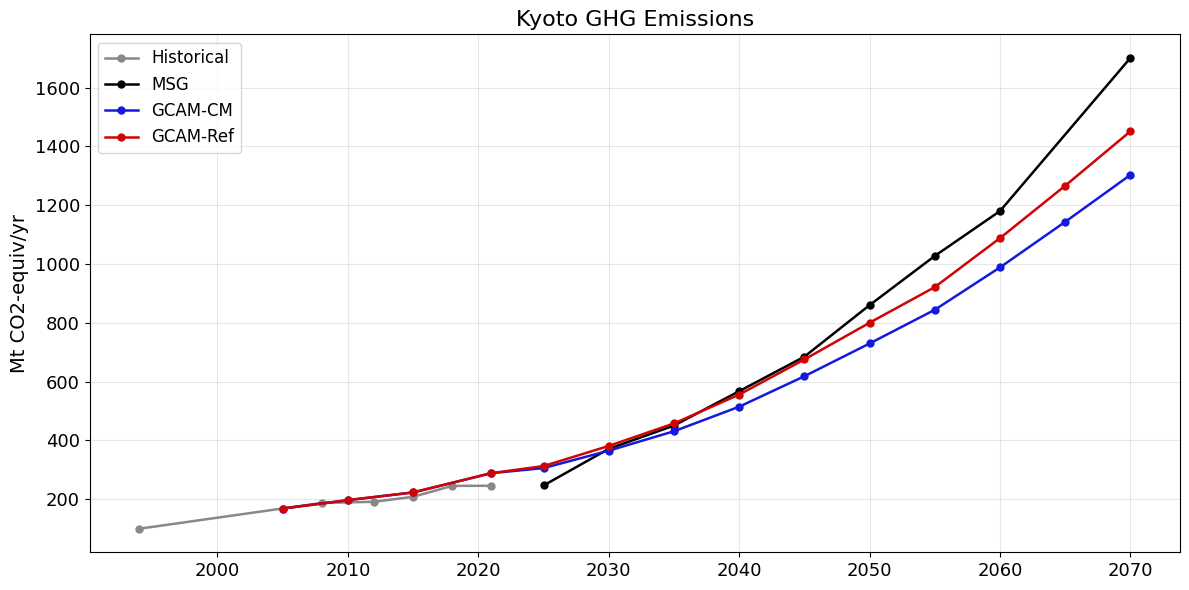

In [65]:
fig, ax = plt.subplots(figsize=(12, 6))

# Historical
ext_years  = [1994, 2008, 2012, 2015, 2018, 2021]
ext_values = [99.0265, 186.8265, 190.791, 207.7, 244.9, 245.2]
ax.plot(ext_years, ext_values, color='#888888', marker='o', markersize=5,
        linestyle='-', linewidth=1.8, label='Historical')

_kyoto_var = {
    'MSG':      'Emissions|Kyoto Gases',
    'GCAM-CM':  'Emissions|Kyoto Gases|Energy and Industrial Processes',
    'GCAM-Ref': 'Emissions|Kyoto Gases|Energy and Industrial Processes',
}

for sname, sdf in SCENARIOS:
    filt = sdf.filter(variable=_kyoto_var[sname])
    if not filt.empty:
        ts = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = yrs <= 2070
        ax.plot(yrs[mask], ts.values[0][mask],
                color=SCENARIO_COLORS[sname], marker=SCENARIO_MARKERS[sname],
                markersize=5, linewidth=1.8, label=sname)

ax.set_ylabel('Mt CO2-equiv/yr', fontsize=14)
ax.set_title('Kyoto GHG Emissions', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. CO2 Emissions from Energy

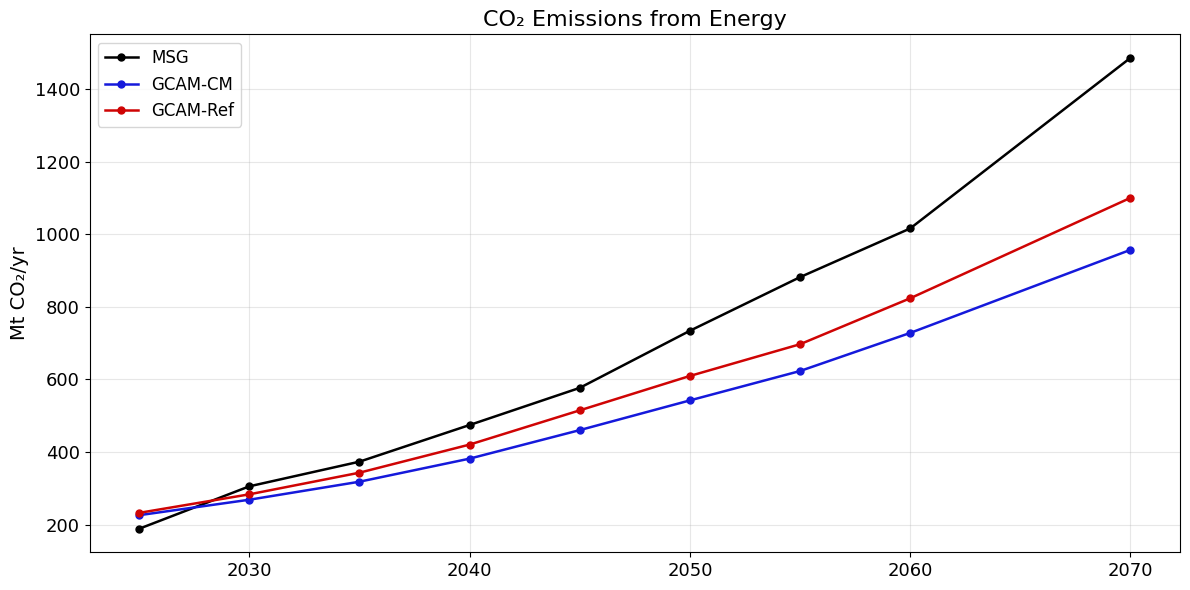

In [66]:
line_comparison(
    'Emissions|CO2|Energy',
    title='CO₂ Emissions from Energy',
    ylabel='Mt CO₂/yr',
    scale=1
)

## 3. Electricity Generation Mix (Secondary Energy)

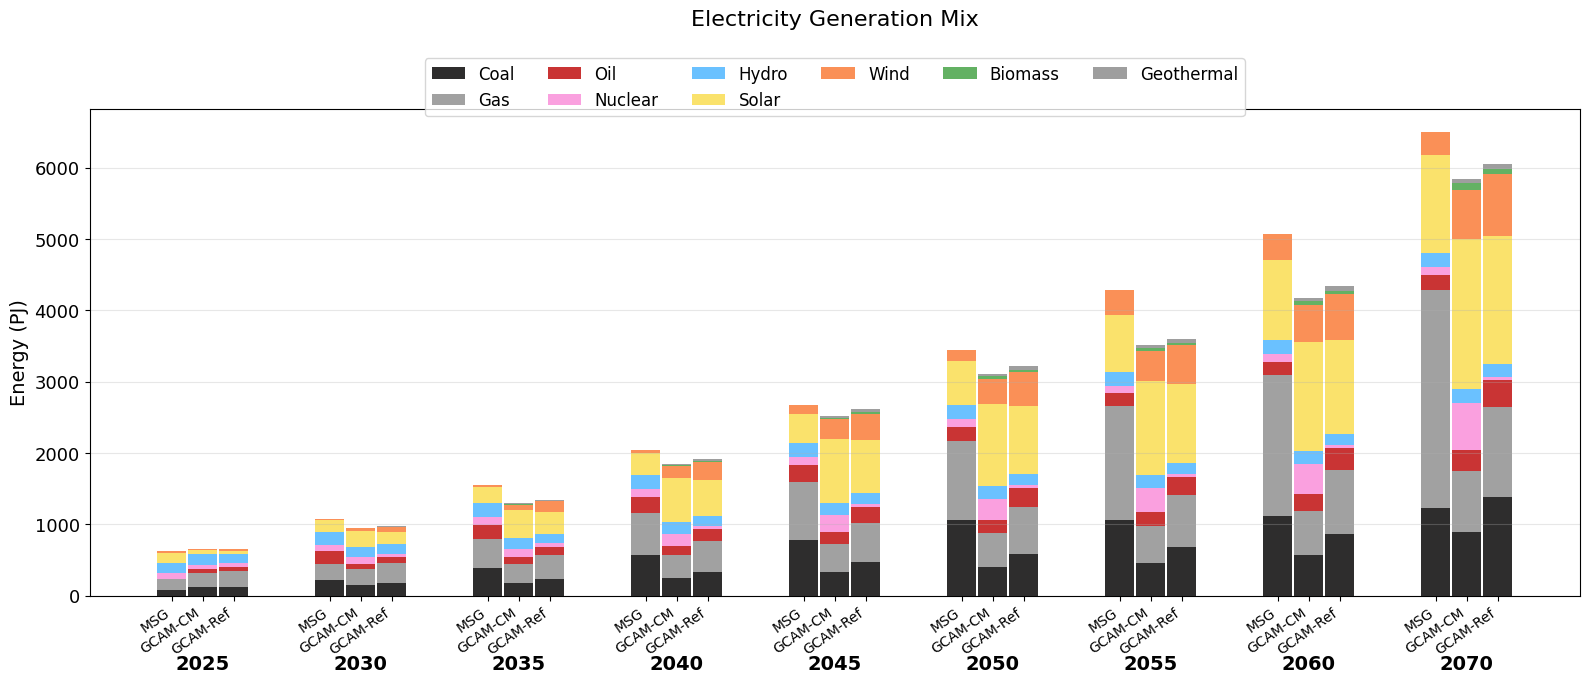

In [67]:
vars_SE = [
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Other',
]
colors_SE = {
    'Secondary Energy|Electricity|Coal':       '#2E2D2D',
    'Secondary Energy|Electricity|Gas':        '#A1A1A1',
    'Secondary Energy|Electricity|Oil':        '#c93434',
    'Secondary Energy|Electricity|Nuclear':    '#faa0df',
    'Secondary Energy|Electricity|Hydro':      '#6ac1ff',
    'Secondary Energy|Electricity|Solar':      '#fae26c',
    'Secondary Energy|Electricity|Wind':       '#fa9057',
    'Secondary Energy|Electricity|Biomass':    '#63b163',
    'Secondary Energy|Electricity|Geothermal': '#9e9e9e',
    'Secondary Energy|Electricity|Other':      '#bdbdbd',
}
labels_SE = {v: v.split('|')[-1] for v in vars_SE}
stacked_bar_comparison(vars_SE, colors_SE, labels_SE, 'Electricity Generation Mix')

## 4. Final Energy - Industry

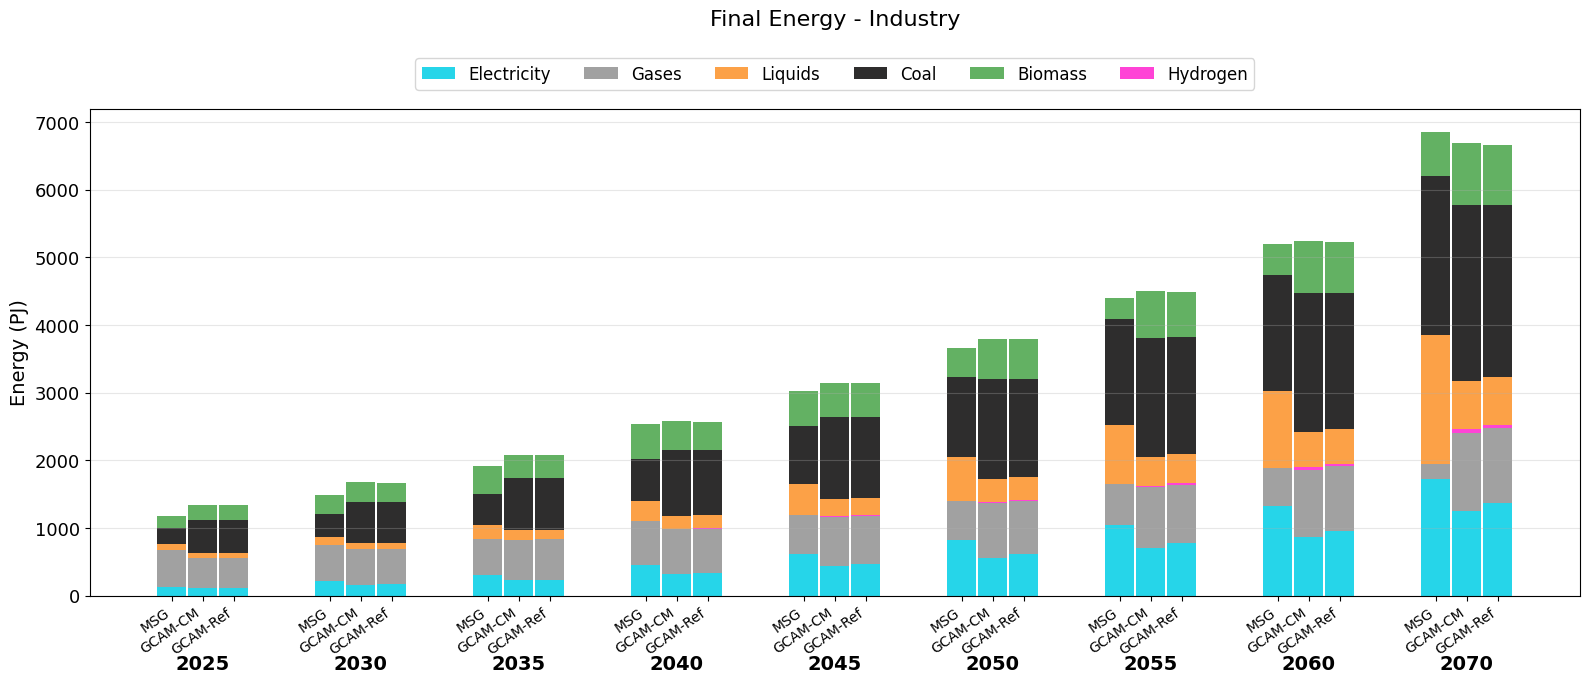

In [68]:
vars_FE_ind = [
    'Final Energy|Industry|Electricity',
    'Final Energy|Industry|Gases',
    'Final Energy|Industry|Hydrogen',
    'Final Energy|Industry|Liquids',
    'Final Energy|Industry|Solids|Coal',
    'Final Energy|Industry|Solids|Biomass',
]
colors_FE_ind = {
    'Final Energy|Industry|Electricity':    '#26d5e9',
    'Final Energy|Industry|Gases':          '#a1a1a1',
    'Final Energy|Industry|Hydrogen':       '#FF43D6',
    'Final Energy|Industry|Liquids':        '#FCA147',
    'Final Energy|Industry|Solids|Coal':    '#2E2D2D',
    'Final Energy|Industry|Solids|Biomass': '#63b163',
}
labels_FE_ind = {v: v.split('|')[-1] for v in vars_FE_ind}
stacked_bar_comparison(vars_FE_ind, colors_FE_ind, labels_FE_ind, 'Final Energy - Industry')

## 5. Final Energy - Residential & Commercial

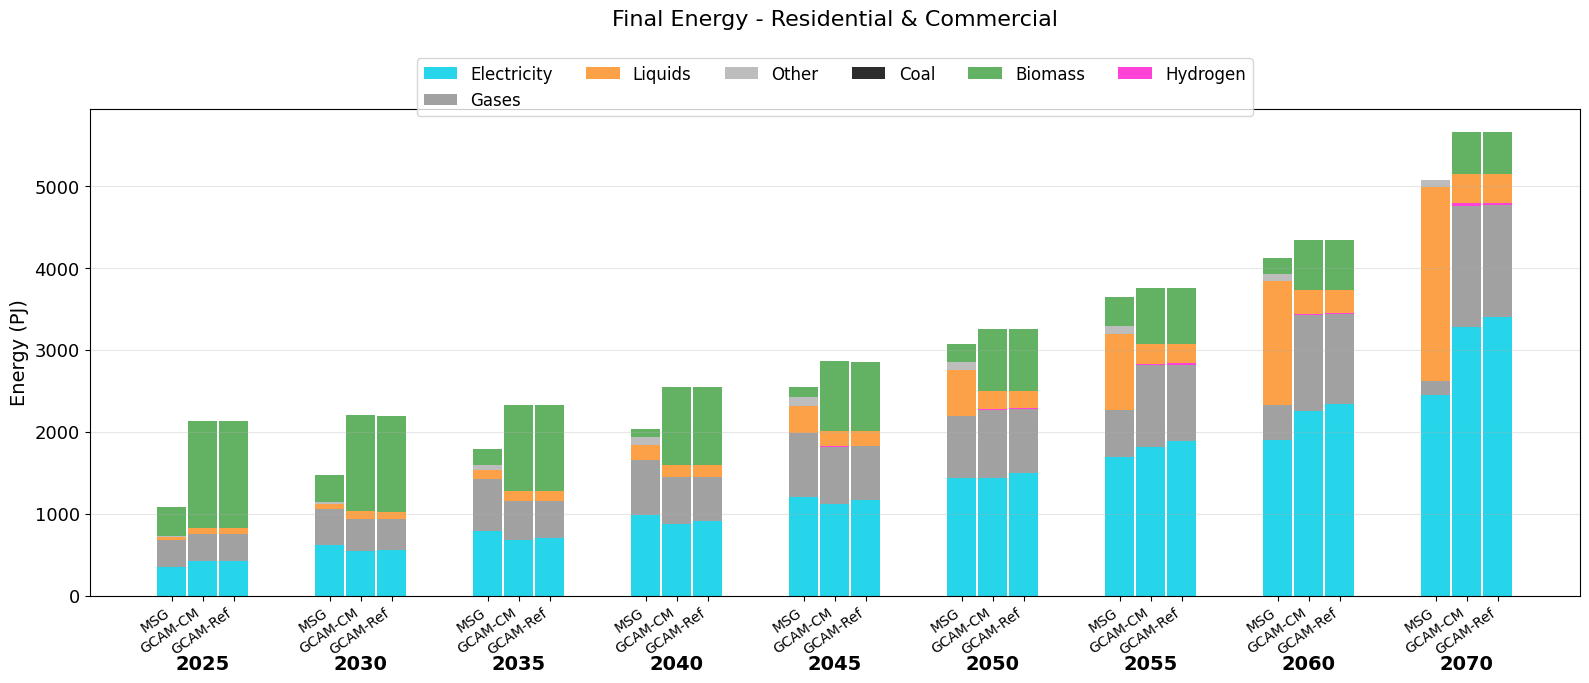

In [69]:
vars_FE_rc = [
    'Final Energy|Residential and Commercial|Electricity',
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Hydrogen',
    'Final Energy|Residential and Commercial|Liquids',
    'Final Energy|Residential and Commercial|Other',
    'Final Energy|Residential and Commercial|Solids|Coal',
    'Final Energy|Residential and Commercial|Solids|Biomass',
]
colors_FE_rc = {
    'Final Energy|Residential and Commercial|Electricity':    '#26d5e9',
    'Final Energy|Residential and Commercial|Gases':          '#a1a1a1',
    'Final Energy|Residential and Commercial|Hydrogen':       '#FF43D6',
    'Final Energy|Residential and Commercial|Liquids':        '#FCA147',
    'Final Energy|Residential and Commercial|Other':          '#bdbdbd',
    'Final Energy|Residential and Commercial|Solids|Coal':    '#2E2D2D',
    'Final Energy|Residential and Commercial|Solids|Biomass': '#63b163',
}
labels_FE_rc = {v: v.split('|')[-1] for v in vars_FE_rc}
stacked_bar_comparison(vars_FE_rc, colors_FE_rc, labels_FE_rc, 'Final Energy - Residential & Commercial')

## 6. Final Energy - Transportation

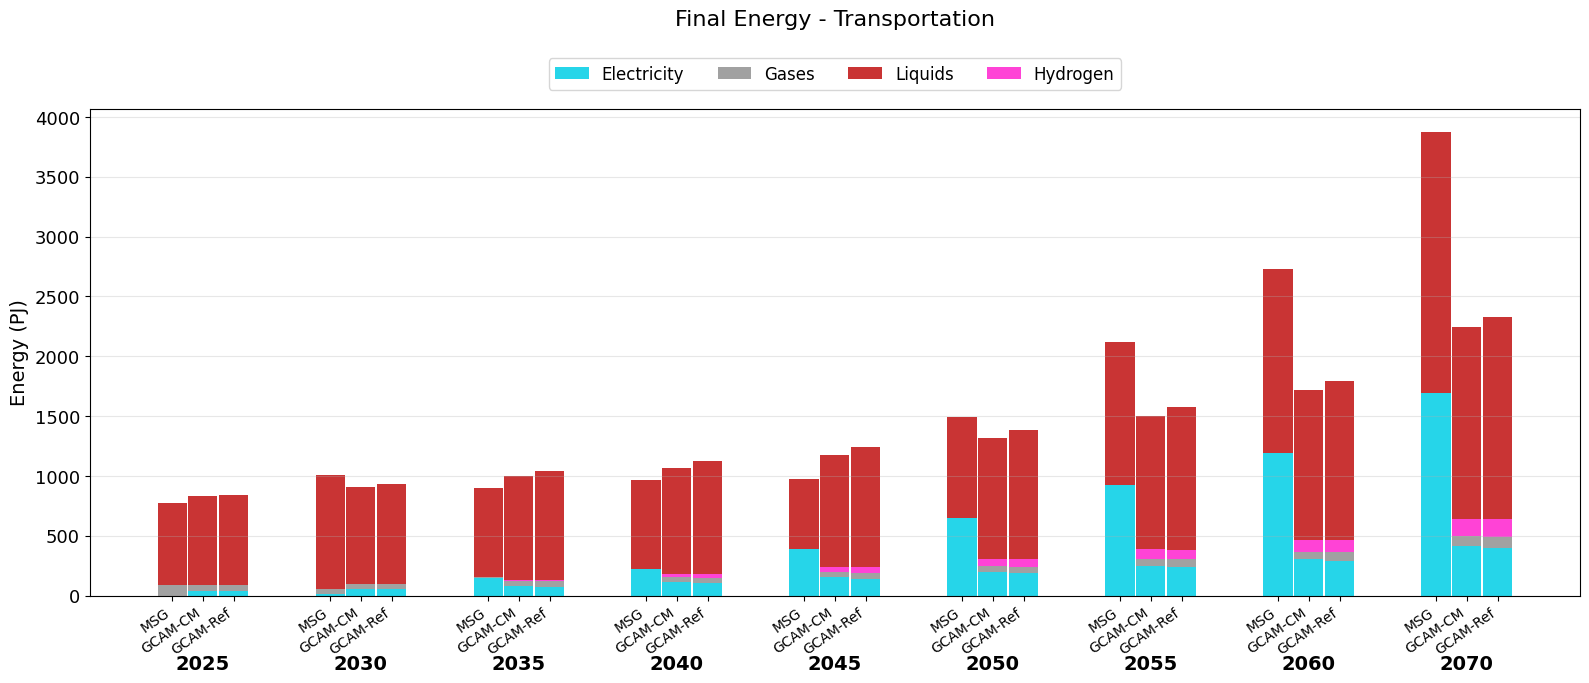

In [70]:
vars_FE_tr = [
    'Final Energy|Transportation|Electricity',
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Hydrogen',
    'Final Energy|Transportation|Liquids',
    'Final Energy|Transportation|Other',
]
colors_FE_tr = {
    'Final Energy|Transportation|Electricity': '#26d5e9',
    'Final Energy|Transportation|Gases':       '#a1a1a1',
    'Final Energy|Transportation|Hydrogen':    '#FF43D6',
    'Final Energy|Transportation|Liquids':     '#c93434',
    'Final Energy|Transportation|Other':       '#fae26c',
}
labels_FE_tr = {v: v.split('|')[-1] for v in vars_FE_tr}
stacked_bar_comparison(vars_FE_tr, colors_FE_tr, labels_FE_tr, 'Final Energy - Transportation')

## 7. Electricity Capacity

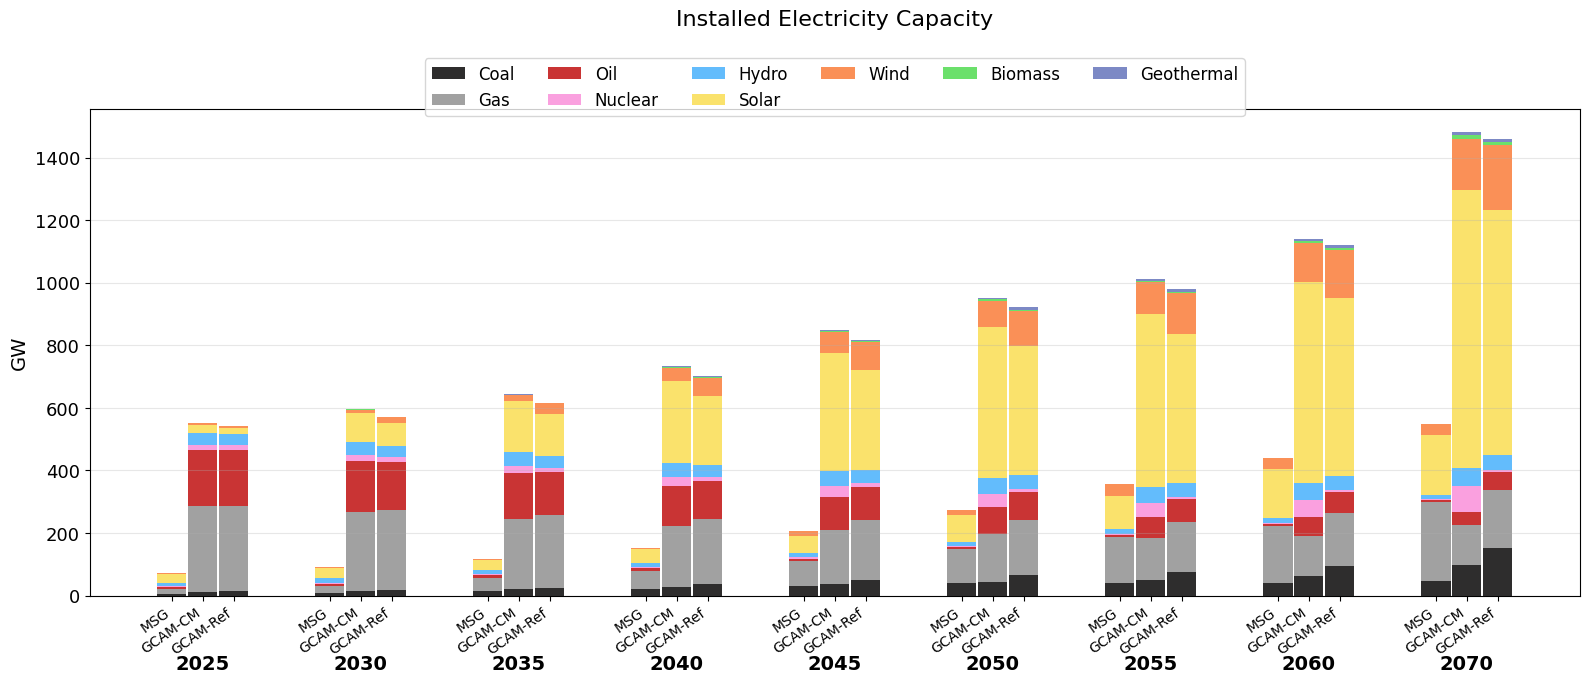

In [71]:
vars_cap = [
    'Capacity|Electricity|Coal',
    'Capacity|Electricity|Gas',
    'Capacity|Electricity|Oil',
    'Capacity|Electricity|Nuclear',
    'Capacity|Electricity|Hydro',
    'Capacity|Electricity|Solar',
    'Capacity|Electricity|Wind',
    'Capacity|Electricity|Biomass',
    'Capacity|Electricity|Geothermal',
]
colors_cap = {
    'Capacity|Electricity|Coal':       '#2E2D2D',
    'Capacity|Electricity|Gas':        '#A1A1A1',
    'Capacity|Electricity|Oil':        '#c93434',
    'Capacity|Electricity|Nuclear':    '#faa0df',
    'Capacity|Electricity|Hydro':      '#63bcfc',
    'Capacity|Electricity|Solar':      '#fae26c',
    'Capacity|Electricity|Wind':       '#fa9057',
    'Capacity|Electricity|Biomass':    '#6be06b',
    'Capacity|Electricity|Geothermal': '#7c89c5',
}
labels_cap = {v: v.split('|')[-1] for v in vars_cap}
stacked_bar_comparison(vars_cap, colors_cap, labels_cap,
                       'Installed Electricity Capacity', ylabel='GW', scale=1)

## 8. CO2 Emissions by Demand Sector

[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:33 - pyam.core: Filtered

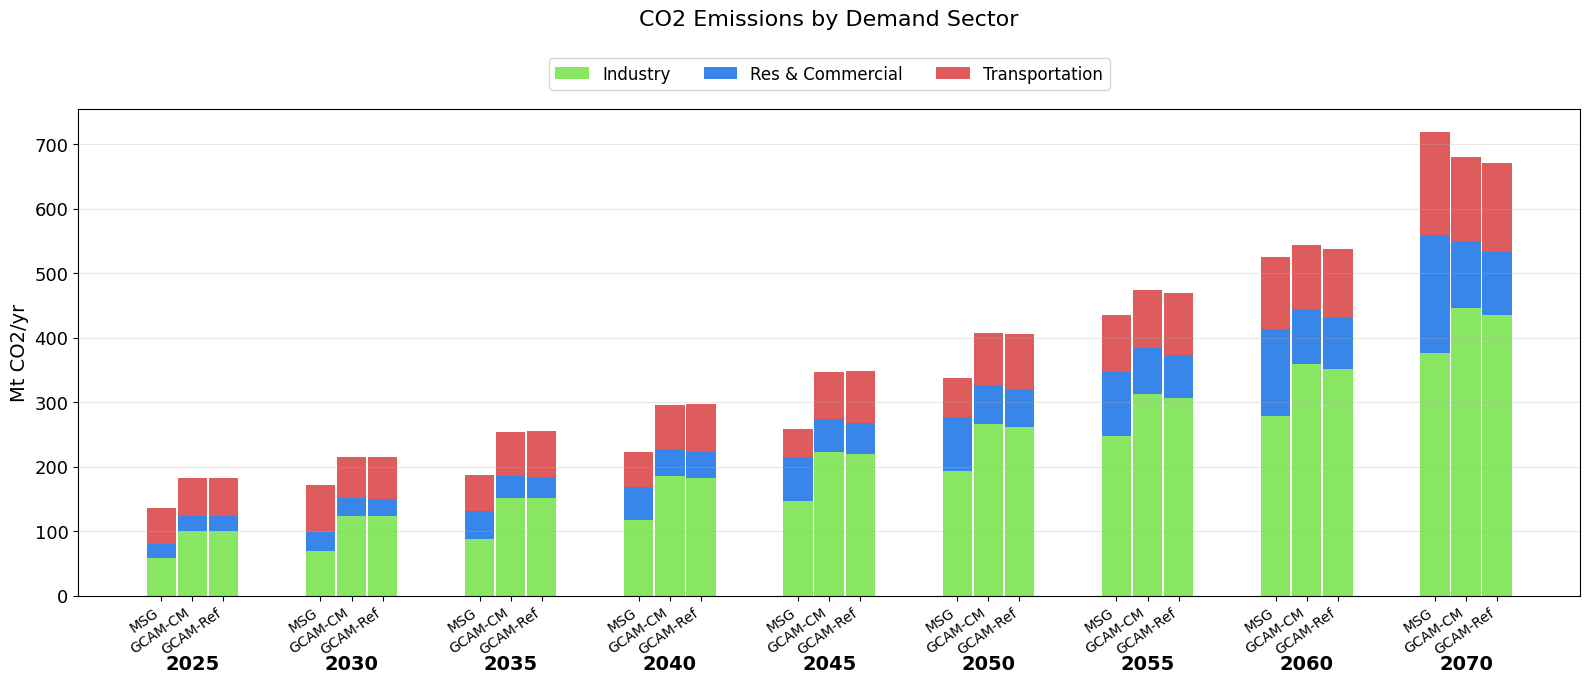

In [72]:
cats = ['Industry', 'Res & Commercial', 'Transportation']
cat_colors = {'Industry': '#88E663', 'Res & Commercial': '#3986eb', 'Transportation': '#df5c5c'}

cat_vars = {
    'Industry':         ['Emissions|CO2|Energy|Demand|Industry',
                         'Emissions|CO2|Energy|Demand|Other Sector'],
    'Res & Commercial': ['Emissions|CO2|Energy|Demand|Residential and Commercial'],
    'Transportation':   ['Emissions|CO2|Energy|Demand|Transportation'],
}

fig, ax = plt.subplots(figsize=(16, 7))
w, gap_year, gap_scen = 0.8, 1.8, 0.05
added, x = set(), 0
year_centers, bar_positions, bar_labels = [], [], []

for yi, year in enumerate(KEY_YEARS):
    if yi > 0:
        x += gap_year
    group_start = x
    for sname, sdf in SCENARIOS:
        bottom = 0
        for cat in cats:
            val = 0
            for var in cat_vars[cat]:
                filt = sdf.filter(variable=var, year=year)
                if not filt.empty:
                    val += filt.timeseries().values[0][0]
            if val <= 0:
                continue
            lbl = cat if cat not in added else ''
            if lbl:
                added.add(cat)
            ax.bar(x, val, w, bottom=bottom, color=cat_colors[cat], label=lbl)
            bottom += val
        bar_positions.append(x)
        bar_labels.append(sname)
        x += w + gap_scen
    year_centers.append((group_start + x - w - gap_scen) / 2)

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, fontsize=10, rotation=35, ha='right')
for center, year in zip(year_centers, KEY_YEARS):
    ax.text(center, -0.12, str(year), transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14, fontweight='bold')

ax.set_ylabel('Mt CO2/yr', fontsize=14)
ax.set_title('CO2 Emissions by Demand Sector', fontsize=16, pad=60)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', ncol=3, fontsize=12,
          frameon=True, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

## 9. CO2 Emissions by Energy Supply

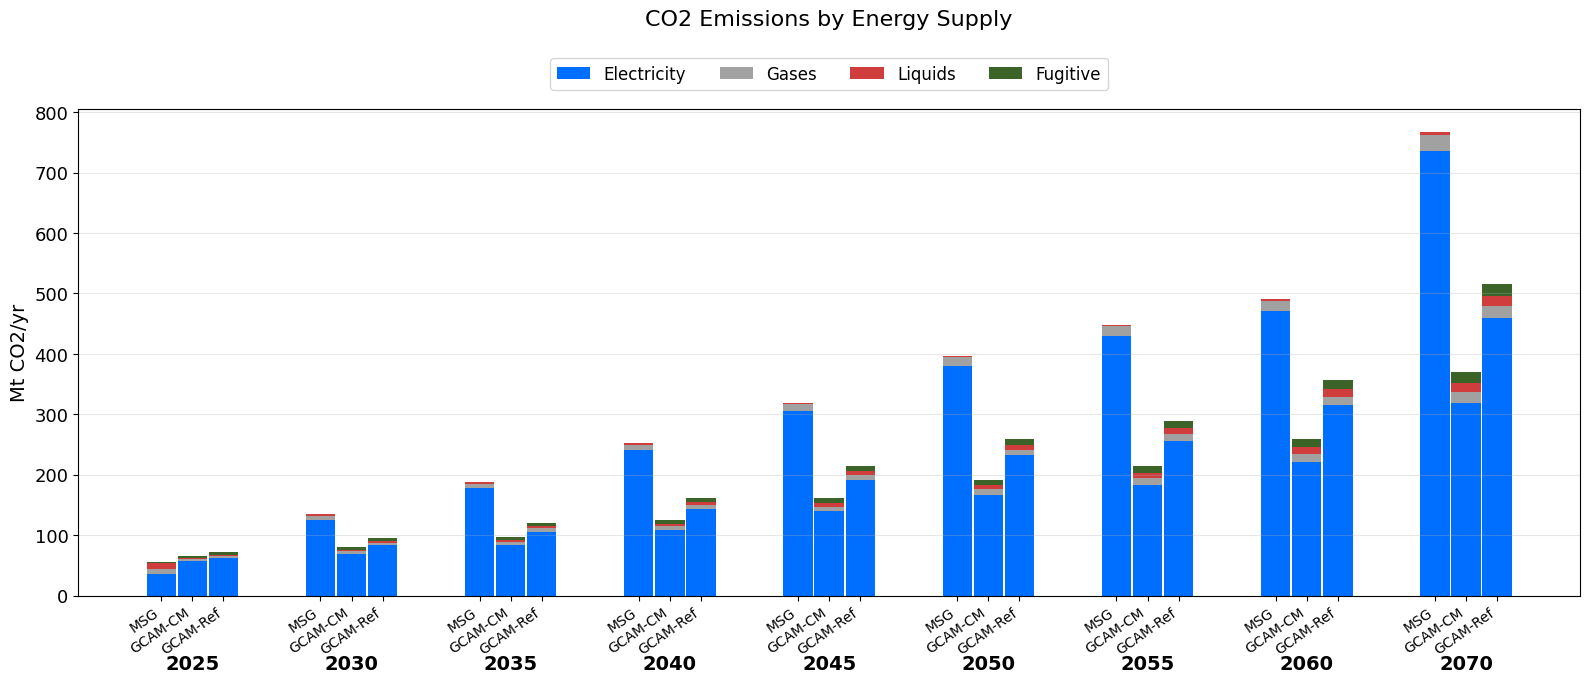

In [73]:
vars_co2_supply = [
    'Emissions|CO2|Energy|Supply|Electricity',
    'Emissions|CO2|Energy|Supply|Gases',
    'Emissions|CO2|Energy|Supply|Liquids',
    'Emissions|CO2|Energy|Supply|Fugitive',
]
colors_co2_supply = {
    'Emissions|CO2|Energy|Supply|Electricity': '#006eff',
    'Emissions|CO2|Energy|Supply|Gases':       '#a1a1a1',
    'Emissions|CO2|Energy|Supply|Liquids':     '#cf3d3d',
    'Emissions|CO2|Energy|Supply|Fugitive':    '#3C6429',
}
labels_co2_supply = {
    'Emissions|CO2|Energy|Supply|Electricity': 'Electricity',
    'Emissions|CO2|Energy|Supply|Gases':       'Gases',
    'Emissions|CO2|Energy|Supply|Liquids':     'Liquids',
    'Emissions|CO2|Energy|Supply|Fugitive':    'Fugitive',
}
stacked_bar_comparison(vars_co2_supply, colors_co2_supply, labels_co2_supply,
                       'CO2 Emissions by Energy Supply', ylabel='Mt CO2/yr', scale=1)

## 10. Emissions by Pollutant - Energy

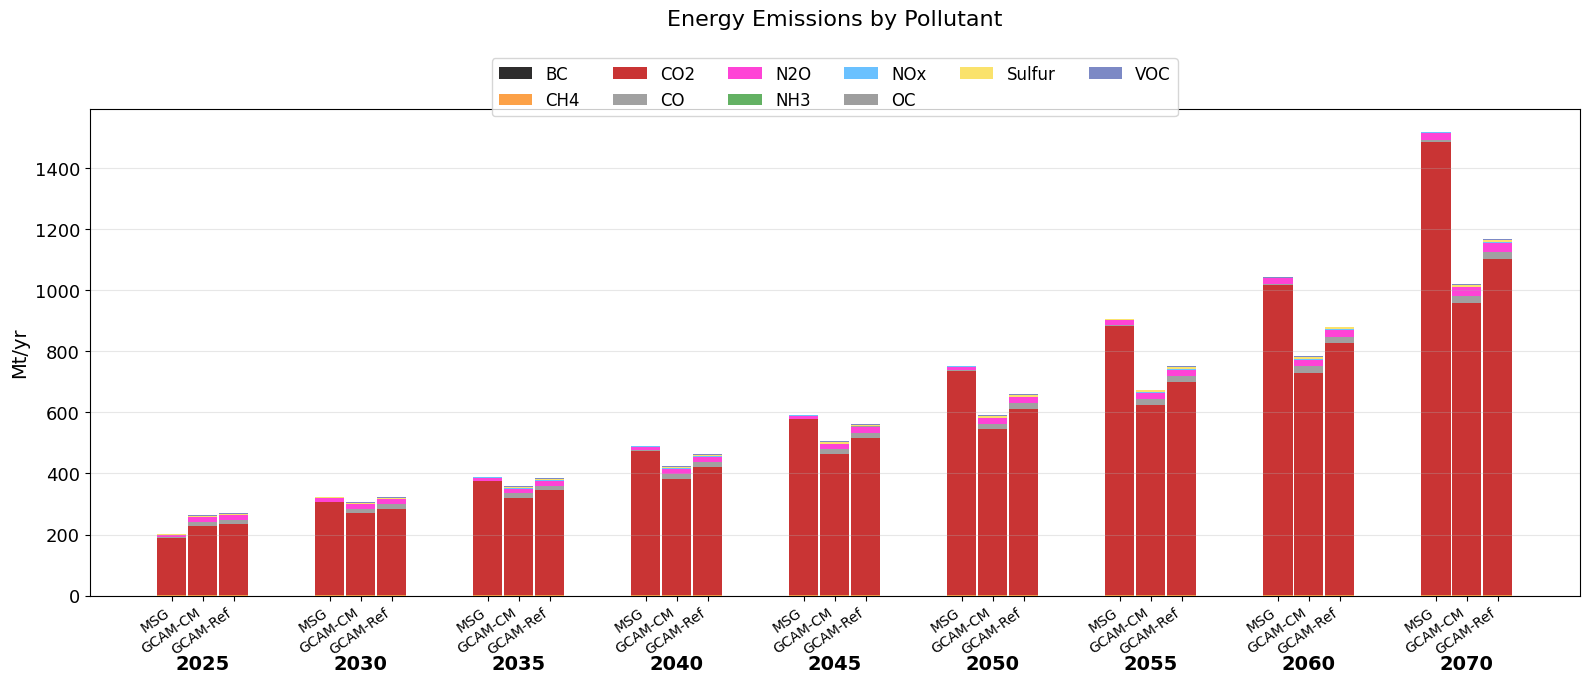

In [74]:
pollutant_colors = {
    'BC': '#2E2D2D', 'CH4': '#FCA147', 'CO2': '#c93434', 'CO': '#a1a1a1',
    'N2O': '#FF43D6', 'NH3': '#63b163', 'NOx': '#6ac1ff', 'OC': '#9e9e9e',
    'Sulfur': '#fae26c', 'VOC': '#7c89c5',
}
vars_energy = [
    'Emissions|BC|Energy', 'Emissions|CH4|Energy', 'Emissions|CO2|Energy',
    'Emissions|CO|Energy', 'Emissions|N2O|Energy', 'Emissions|NH3|Energy',
    'Emissions|NOx|Energy', 'Emissions|OC|Energy', 'Emissions|Sulfur|Energy',
    'Emissions|VOC|Energy',
]
colors_energy = {v: pollutant_colors[v.split('|')[1]] for v in vars_energy}
labels_energy = {v: v.split('|')[1] for v in vars_energy}
stacked_bar_comparison(vars_energy, colors_energy, labels_energy,
                       'Energy Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 11. Emissions by Pollutant - Industrial Processes

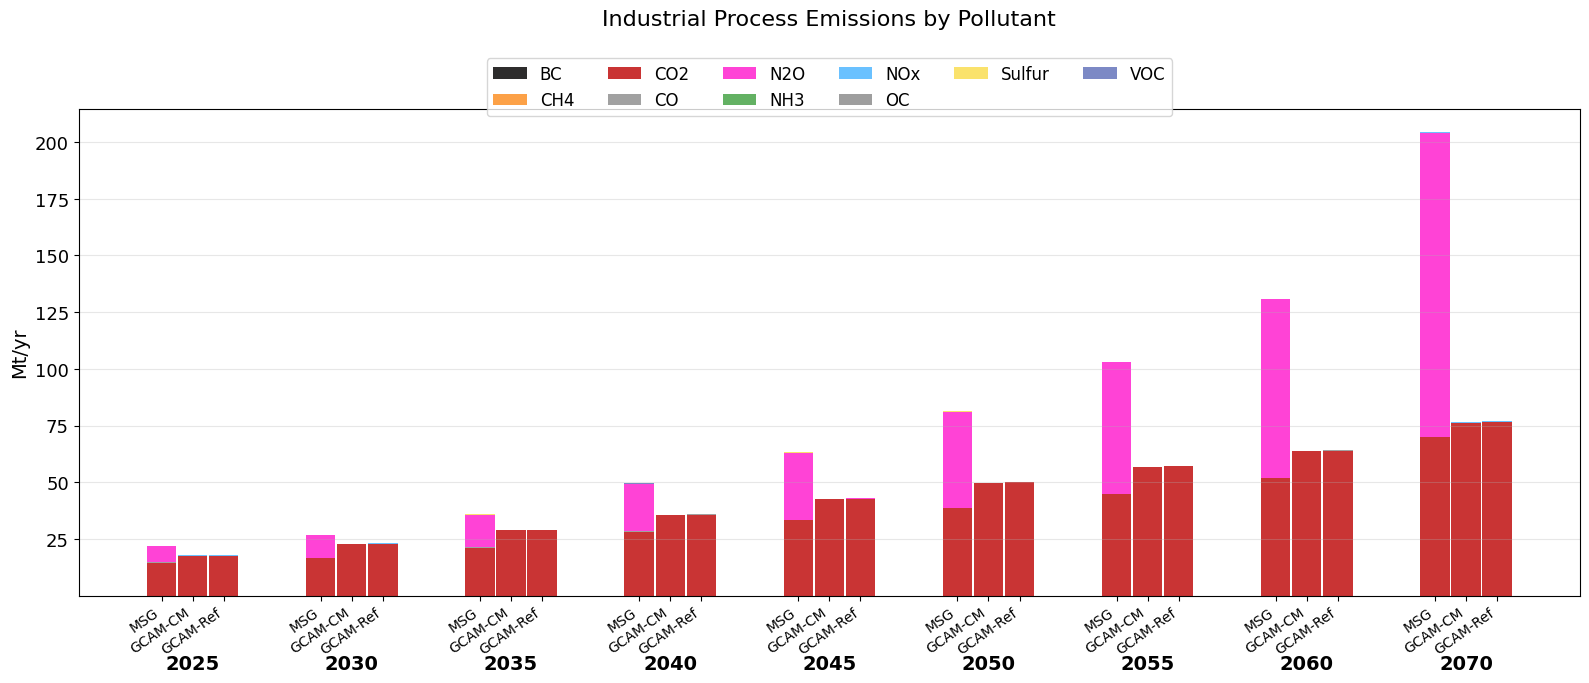

In [75]:
vars_indproc = [
    'Emissions|BC|Industrial Processes', 'Emissions|CH4|Industrial Processes',
    'Emissions|CO2|Industrial Processes', 'Emissions|CO|Industrial Processes',
    'Emissions|N2O|Industrial Processes', 'Emissions|NH3|Industrial Processes',
    'Emissions|NOx|Industrial Processes', 'Emissions|OC|Industrial Processes',
    'Emissions|Sulfur|Industrial Processes', 'Emissions|VOC|Industrial Processes',
]
colors_indproc = {v: pollutant_colors[v.split('|')[1]] for v in vars_indproc}
labels_indproc = {v: v.split('|')[1] for v in vars_indproc}
stacked_bar_comparison(vars_indproc, colors_indproc, labels_indproc,
                       'Industrial Process Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 12. Emissions by Pollutant - Waste

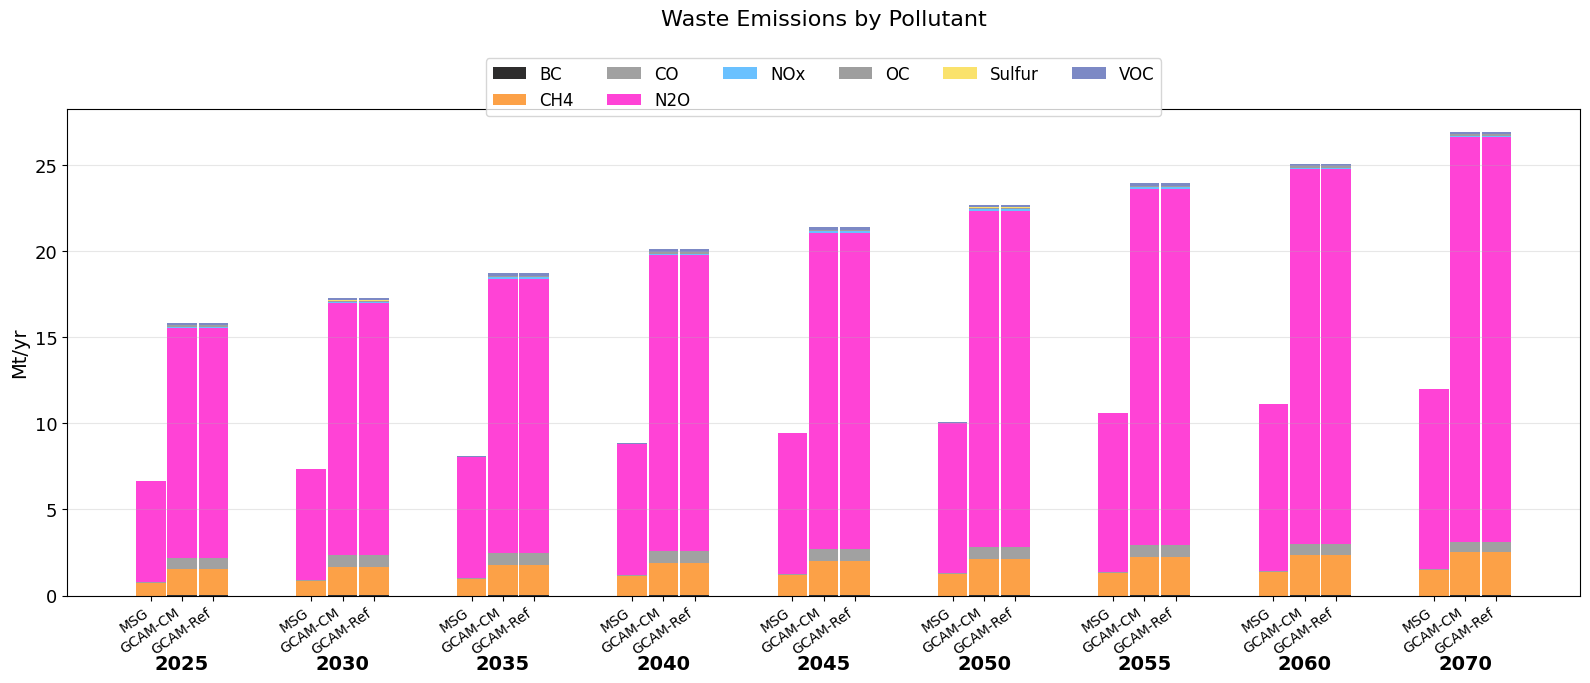

In [76]:
vars_waste = [
    'Emissions|BC|Waste', 'Emissions|CH4|Waste', 'Emissions|CO|Waste',
    'Emissions|N2O|Waste', 'Emissions|NOx|Waste', 'Emissions|OC|Waste',
    'Emissions|Sulfur|Waste', 'Emissions|VOC|Waste',
]
colors_waste = {v: pollutant_colors[v.split('|')[1]] for v in vars_waste}
labels_waste = {v: v.split('|')[1] for v in vars_waste}
stacked_bar_comparison(vars_waste, colors_waste, labels_waste,
                       'Waste Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 13. Total Final Energy by Fuel

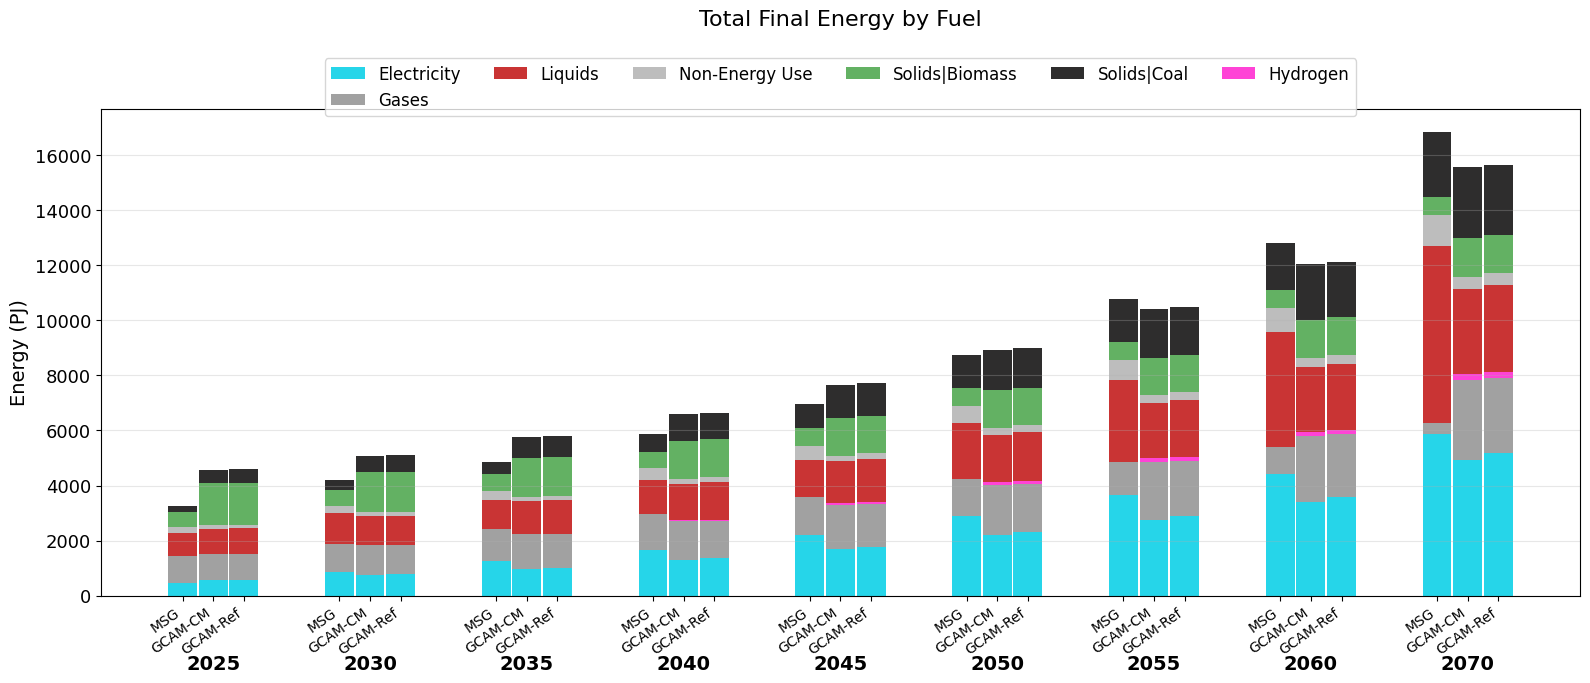

In [77]:
vars_FE_total = [
    'Final Energy|Electricity',
    'Final Energy|Gases',
    'Final Energy|Hydrogen',
    'Final Energy|Liquids',
    'Final Energy|Non-Energy Use',
    'Final Energy|Solids|Biomass',
    'Final Energy|Solids|Coal',
]
colors_FE_total = {
    'Final Energy|Electricity':    '#26d5e9',
    'Final Energy|Gases':          '#a1a1a1',
    'Final Energy|Hydrogen':       '#FF43D6',
    'Final Energy|Liquids':        '#c93434',
    'Final Energy|Non-Energy Use': '#bdbdbd',
    'Final Energy|Solids|Biomass': '#63b163',
    'Final Energy|Solids|Coal':    '#2E2D2D',
}
labels_FE_total = {v: v.replace('Final Energy|', '') for v in vars_FE_total}
stacked_bar_comparison(vars_FE_total, colors_FE_total, labels_FE_total,
                       'Total Final Energy by Fuel', scale=1)

## 14. Primary Energy Mix

[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:41 - pyam.core: Filtered

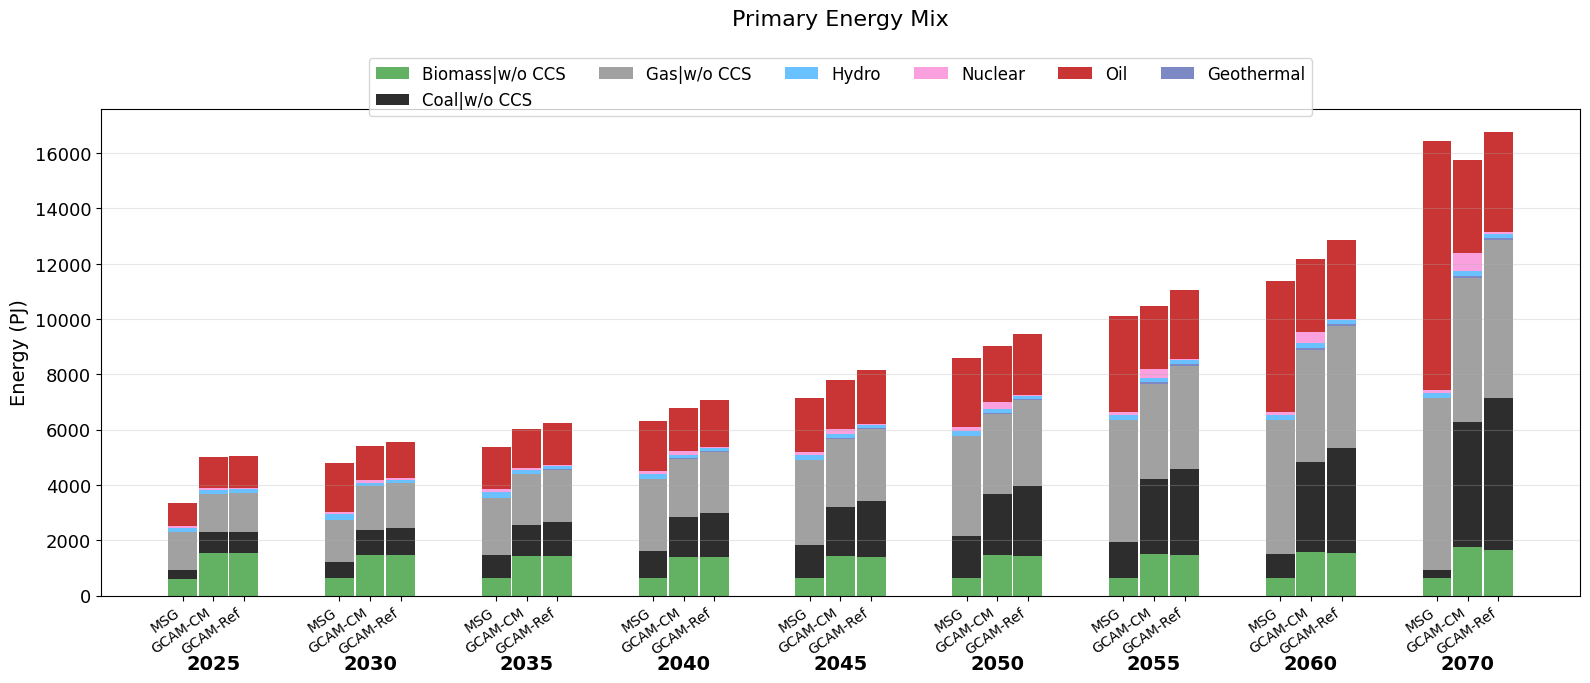

In [78]:
vars_PE = [
    'Primary Energy|Biomass|w/ CCS',
    'Primary Energy|Biomass|w/o CCS',
    'Primary Energy|Coal|w/ CCS',
    'Primary Energy|Coal|w/o CCS',
    'Primary Energy|Gas|w/ CCS',
    'Primary Energy|Gas|w/o CCS',
    'Primary Energy|Geothermal',
    'Primary Energy|Hydro',
    'Primary Energy|Nuclear',
    'Primary Energy|Ocean',
    'Primary Energy|Oil',
    'Primary Energy|Other',
]
colors_PE = {
    'Primary Energy|Biomass|w/ CCS':  '#2d7a2d',
    'Primary Energy|Biomass|w/o CCS': '#63b163',
    'Primary Energy|Coal|w/ CCS':     '#1a1a1a',
    'Primary Energy|Coal|w/o CCS':    '#2E2D2D',
    'Primary Energy|Gas|w/ CCS':      '#787878',
    'Primary Energy|Gas|w/o CCS':     '#A1A1A1',
    'Primary Energy|Geothermal':      '#7c89c5',
    'Primary Energy|Hydro':           '#6ac1ff',
    'Primary Energy|Nuclear':         '#faa0df',
    'Primary Energy|Ocean':           '#26d5e9',
    'Primary Energy|Oil':             '#c93434',
    'Primary Energy|Other':           '#bdbdbd',
}
labels_PE = {v: v.replace('Primary Energy|', '') for v in vars_PE}
stacked_bar_comparison(vars_PE, colors_PE, labels_PE, 'Primary Energy Mix')

## 15. Trade - Primary Energy Volumes

[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:43 - pyam.core: Filtered

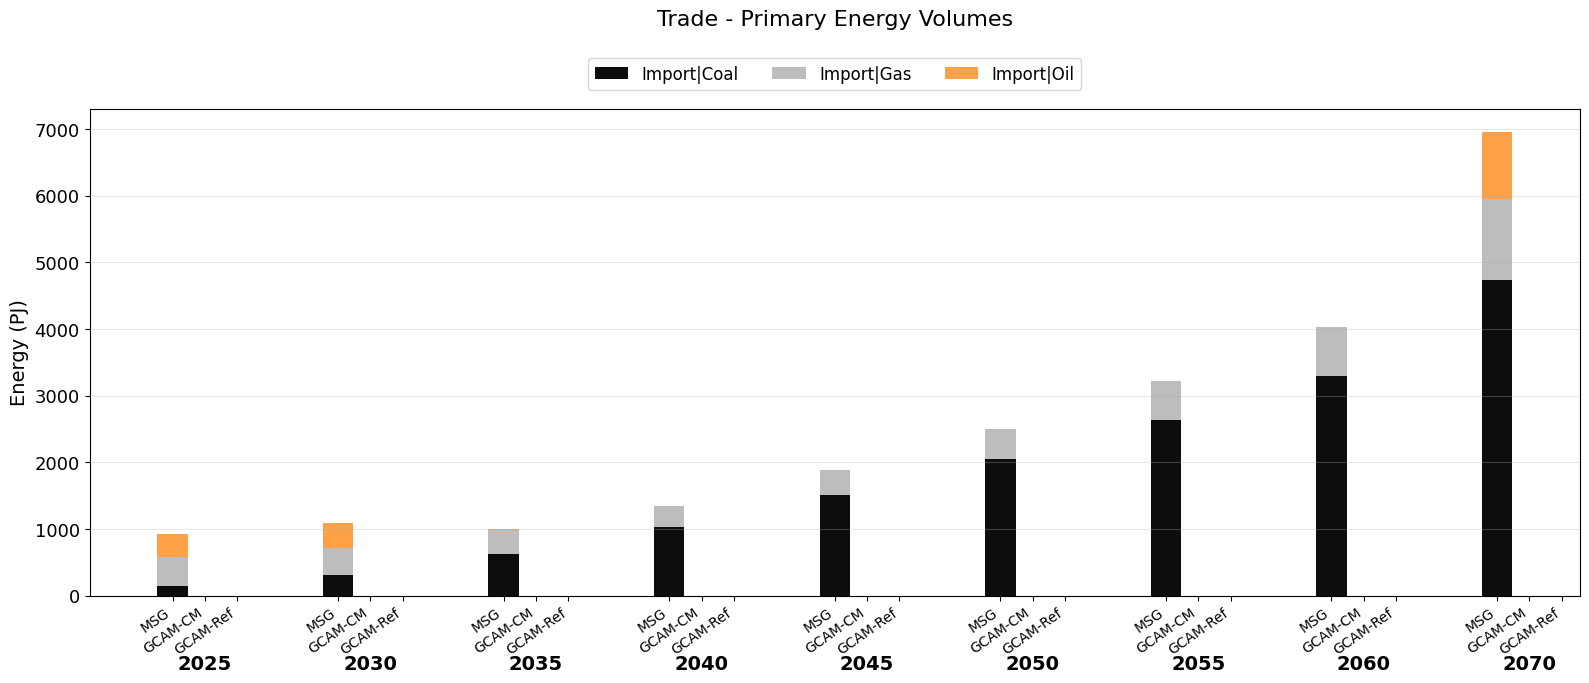

In [79]:
vars_trade_PE = [
    'Trade|Gross Export|Primary Energy|Biomass|Volume',
    'Trade|Gross Export|Primary Energy|Coal|Volume',
    'Trade|Gross Export|Primary Energy|Gas|Volume',
    'Trade|Gross Export|Primary Energy|Oil|Volume',
    'Trade|Gross Import|Primary Energy|Biomass|Volume',
    'Trade|Gross Import|Primary Energy|Coal|Volume',
    'Trade|Gross Import|Primary Energy|Gas|Volume',
    'Trade|Gross Import|Primary Energy|Oil|Volume',
]
colors_trade_PE = {
    'Trade|Gross Export|Primary Energy|Biomass|Volume': '#2d7a2d',
    'Trade|Gross Export|Primary Energy|Coal|Volume':    "#0E0D0D",
    'Trade|Gross Export|Primary Energy|Gas|Volume':     '#A1A1A1',
    'Trade|Gross Export|Primary Energy|Oil|Volume':     '#c93434',
    'Trade|Gross Import|Primary Energy|Biomass|Volume': '#63b163',
    'Trade|Gross Import|Primary Energy|Coal|Volume':    '#0E0D0D',
    'Trade|Gross Import|Primary Energy|Gas|Volume':     '#bdbdbd',
    'Trade|Gross Import|Primary Energy|Oil|Volume':     '#FCA147',
}
labels_trade_PE = {
    'Trade|Gross Export|Primary Energy|Biomass|Volume': 'Export|Biomass',
    'Trade|Gross Export|Primary Energy|Coal|Volume':    'Export|Coal',
    'Trade|Gross Export|Primary Energy|Gas|Volume':     'Export|Gas',
    'Trade|Gross Export|Primary Energy|Oil|Volume':     'Export|Oil',
    'Trade|Gross Import|Primary Energy|Biomass|Volume': 'Import|Biomass',
    'Trade|Gross Import|Primary Energy|Coal|Volume':    'Import|Coal',
    'Trade|Gross Import|Primary Energy|Gas|Volume':     'Import|Gas',
    'Trade|Gross Import|Primary Energy|Oil|Volume':     'Import|Oil',
}
stacked_bar_comparison(vars_trade_PE, colors_trade_PE, labels_trade_PE,
                       'Trade - Primary Energy Volumes')

## 16. Trade - Secondary Energy Volumes

[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:44 - pyam.core: Filtered

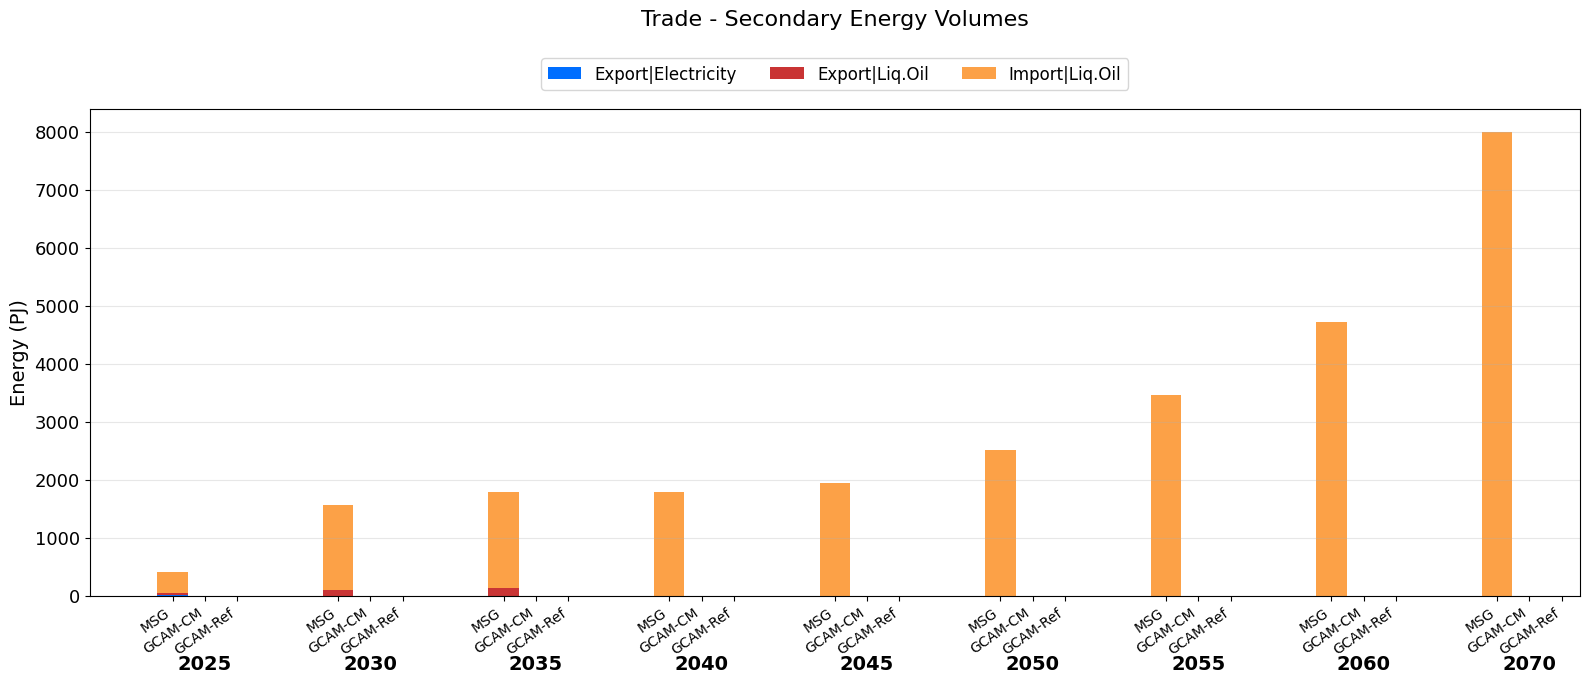

In [80]:
vars_trade_SE = [
    'Trade|Gross Export|Secondary Energy|Electricity|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume',
]
colors_trade_SE = {
    'Trade|Gross Export|Secondary Energy|Electricity|Volume':     '#006eff',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume': '#2d7a2d',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume':    '#2E2D2D',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume':     '#c93434',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume':     '#26d5e9',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume': '#63b163',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume':    '#787878',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume':     '#FCA147',
}
labels_trade_SE = {
    'Trade|Gross Export|Secondary Energy|Electricity|Volume':     'Export|Electricity',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume': 'Export|Liq.Biomass',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume':    'Export|Liq.Coal',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume':     'Export|Liq.Oil',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume':     'Import|Electricity',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume': 'Import|Liq.Biomass',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume':    'Import|Liq.Coal',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume':     'Import|Liq.Oil',
}
stacked_bar_comparison(vars_trade_SE, colors_trade_SE, labels_trade_SE,
                       'Trade - Secondary Energy Volumes')

## 17. Resource Extraction

[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:22:46 - pyam.core: Filtered

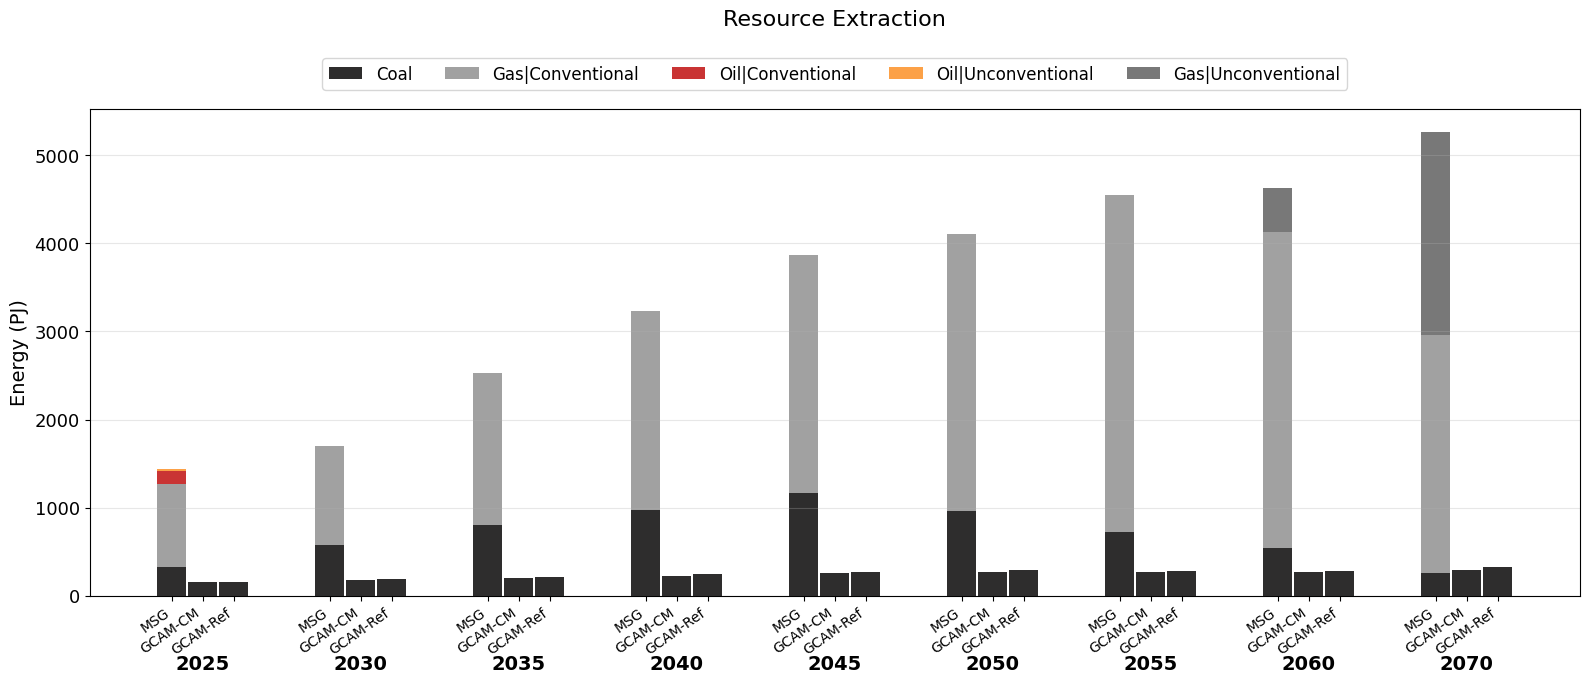

In [81]:
vars_res = [
    'Resource|Extraction|Coal',
    'Resource|Extraction|Gas|Conventional',
    'Resource|Extraction|Gas|Unconventional',
    'Resource|Extraction|Oil|Conventional',
    'Resource|Extraction|Oil|Unconventional',
]
colors_res = {
    'Resource|Extraction|Coal':               '#2E2D2D',
    'Resource|Extraction|Gas|Conventional':   '#A1A1A1',
    'Resource|Extraction|Gas|Unconventional': '#787878',
    'Resource|Extraction|Oil|Conventional':   '#c93434',
    'Resource|Extraction|Oil|Unconventional': '#FCA147',
}
labels_res = {
    'Resource|Extraction|Coal':               'Coal',
    'Resource|Extraction|Gas|Conventional':   'Gas|Conventional',
    'Resource|Extraction|Gas|Unconventional': 'Gas|Unconventional',
    'Resource|Extraction|Oil|Conventional':   'Oil|Conventional',
    'Resource|Extraction|Oil|Unconventional': 'Oil|Unconventional',
}
stacked_bar_comparison(vars_res, colors_res, labels_res, 'Resource Extraction')